**Early Detection of Chronic Kidney Disease Using Machine Learning Algorithms**

In [ ]:
# Import required libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           roc_curve, auc, roc_auc_score)

In [ ]:
# Data Exploration:

df = pd.read_csv("kidney_disease(before).csv")

# Initial dataset information
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1] - 1}")
print(f"Number of Samples: {df.shape[0]}")

# Display basic info
print("\n1.2 Dataset Information:")
print("-" * 40)
print(df.info())


Dataset Shape: (400, 26)
Number of Features: 25
Number of Samples: 400

1.2 Dataset Information:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null   

In [ ]:
# Data Preprocessing:

# Drop ID column as it's not useful for prediction
df.drop(columns=['id'], inplace=True)

# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Handle missing values
from sklearn.impute import SimpleImputer
# 1- Handle numerical missing values with median
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])
# 2- Handle categorical missing values with most frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Encode target variable safely
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})
# Drop rows with NaN in classification
df = df.dropna(subset=['classification'])
# Convert to int
df['classification'] = df['classification'].astype(int)

# Clean categorical data
for col in cat_cols:
    if col != 'classification':
        df[col] = df[col].astype(str).str.strip()


# Replace non-standard missing indicators
df.replace(['?', '\t?', 'nan', 'NaN', 'Na'], np.nan, inplace=True)

# Fix numerical columns stored as strings
num_fix_cols = ['pcv', 'wc', 'rc']
for col in num_fix_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

# Encode categorical features
# Binary categorical columns (yes/no)
binary_cols = ['htn', 'dm', 'cad', 'pe', 'ane']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Other categorical columns
df['rbc'] = df['rbc'].map({'normal': 1, 'abnormal': 0})
df['pc'] = df['pc'].map({'normal': 1, 'abnormal': 0})
df['pcc'] = df['pcc'].map({'present': 1, 'notpresent': 0})
df['ba'] = df['ba'].map({'present': 1, 'notpresent': 0})
df['appet'] = df['appet'].map({'good': 1, 'poor': 0})



/tmp/ipython-input-3936439766.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


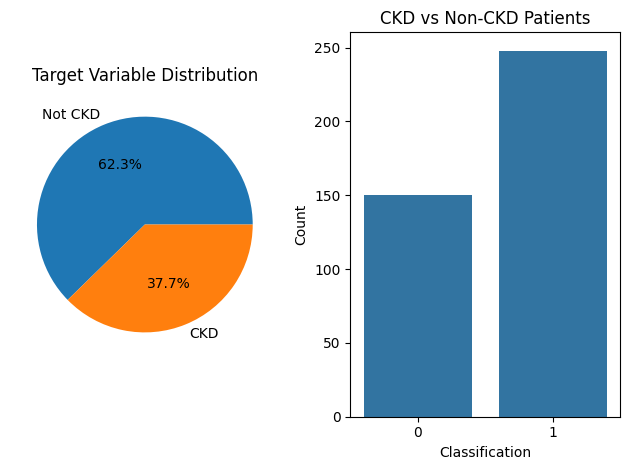


3.2 Statistical Summary:
----------------------------------------
          age      bp      sg      al      su     rbc      pc    pcc      ba  \
count  398.00  398.00  398.00  398.00  398.00  398.00  398.00  398.0  398.00   
mean    51.48   76.61    1.02    0.90    0.40    0.88    0.81    0.1    0.06   
std     16.98   13.50    0.01    1.31    1.04    0.32    0.39    0.3    0.23   
min      2.00   50.00    1.00    0.00    0.00    0.00    0.00    0.0    0.00   
25%     42.00   70.00    1.01    0.00    0.00    1.00    1.00    0.0    0.00   
50%     55.00   80.00    1.02    0.00    0.00    1.00    1.00    0.0    0.00   
75%     64.00   80.00    1.02    2.00    0.00    1.00    1.00    0.0    0.00   
max     90.00  180.00    1.02    5.00    5.00    1.00    1.00    1.0    1.00   

          bgr  ...     pcv        wc      rc     htn      dm     cad  appet  \
count  398.00  ...  398.00    398.00  398.00  398.00  398.00  398.00  398.0   
mean   144.96  ...   39.28   8777.39    4.87    0.36  

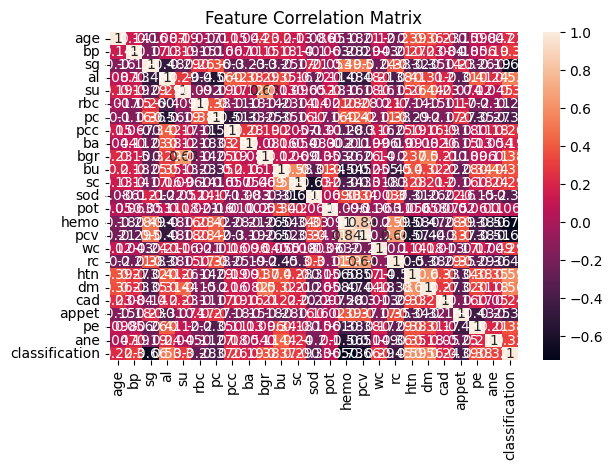


3.3 Top 10 Features Correlated with CKD:
----------------------------------------
 1. htn                      : 0.5888
 2. dm                       : 0.5572
 3. al                       : 0.5329
 4. bgr                      : 0.3791
 5. pe                       : 0.3778
 6. bu                       : 0.3715
 7. ane                      : 0.3244
 8. bp                       : 0.2966
 9. su                       : 0.2966
10. sc                       : 0.2920


In [ ]:
# Exploratory Data Aanalysis:

# Target distribution
plt.figure()

# Pie chart for target distribution
plt.subplot(1, 2, 1)
target_counts = df['classification'].value_counts()
plt.pie(target_counts.values, labels=['Not CKD', 'CKD'], autopct='%1.1f%%')
plt.title('Target Variable Distribution')

# Bar chart for target distribution
plt.subplot(1, 2, 2)
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('CKD vs Non-CKD Patients')
plt.xlabel('Classification')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 3.2 Statistical summary
print("\n3.2 Statistical Summary:")
print("-" * 40)
print(df.describe().round(2))

# 3.3 Correlation matrix
plt.figure()
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 3.4 Top features correlated with target
correlation_with_target = correlation_matrix['classification'].sort_values(ascending=False)
print("\n3.3 Top 10 Features Correlated with CKD:")
print("-" * 40)
for i, (feature, corr) in enumerate(correlation_with_target[1:11].items(), 1):
    print(f"{i:2d}. {feature:25s}: {corr:.4f}")


In [ ]:
# Data Preparation for Modeling:

# Separate features and target
X = df.drop(columns=['classification'])
y = df['classification']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# Model Training and Evaluation:

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Store results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': model_name,
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}"
    })

# Display results in a table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                         Model Accuracy Precision Recall F1-Score
           Logistic Regression   1.0000    1.0000 1.0000   1.0000
Logistic Regression (Balanced)   1.0000    1.0000 1.0000   1.0000
                 Decision Tree   0.9625    1.0000 0.9400   0.9691
                 Random Forest   1.0000    1.0000 1.0000   1.0000


In [ ]:
# Hyperparameter Tuning (Logistic Regression):

# Define parameter grid for Logistic Regression
log_reg_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# GridSearchCV for Logistic Regression
log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_reg_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X_train_scaled, y_train)

print(f"\nBest Logistic Regression Parameters: {log_reg_grid.best_params_}")
print(f"Best Cross-Validation Score: {log_reg_grid.best_score_:.4f}")

# Evaluate tuned Logistic Regression
log_reg_best = log_reg_grid.best_estimator_
y_pred_log_reg = log_reg_best.predict(X_test_scaled)

log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print(f"\nTest Accuracy (Tuned Logistic Regression): {log_reg_accuracy:.4f}")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall: {log_reg_recall:.4f}")
print(f"F1-Score: {log_reg_f1:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Logistic Regression Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation Score: 0.9938

Test Accuracy (Tuned Logistic Regression): 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


CV Scores: [1.     1.     0.9375 1.     0.9688 1.     1.     1.     1.     1.    ]
Mean Accuracy: 0.9906
Std Deviation: 0.0200


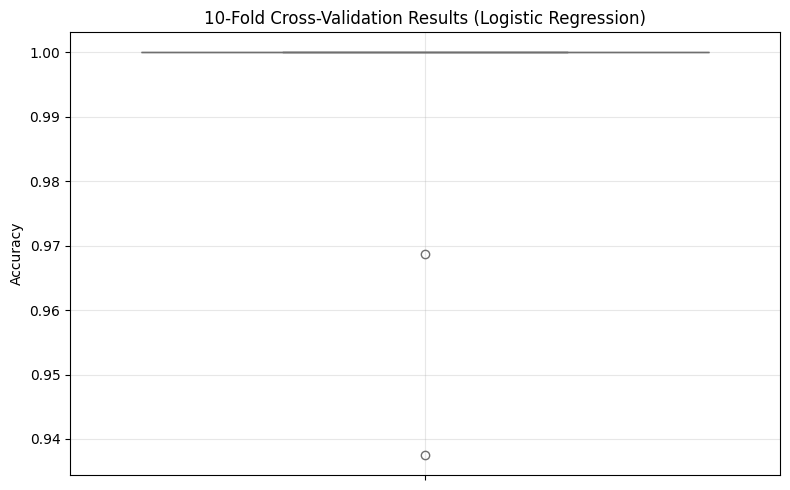

In [ ]:
# Cross-Validation and Model Stability:

cv_scores = cross_val_score(
    log_reg_best,
    X_train_scaled,
    y_train,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_scores, color='skyblue')
plt.title('10-Fold Cross-Validation Results (Logistic Regression)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

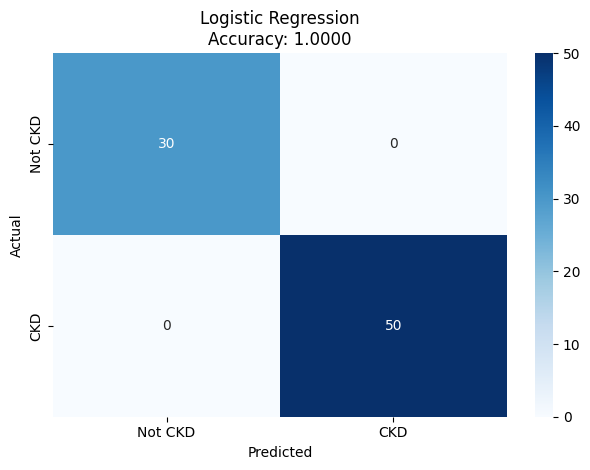

In [ ]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.title(f'Logistic Regression\nAccuracy: {log_reg_accuracy:.4f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# Final Results

print(f"Best Performing Model: Logistic Regression")
print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall: {log_reg_recall:.4f}")
print(f"F1-Score: {log_reg_f1:.4f}")

Best Performing Model: Logistic Regression
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
